1. Load data
2. Correlation analysis
3. Hypothesis testing
4. Regression analysis
5. Findings summary

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind, chi2_contingency
import statsmodels.api as sm


sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [10]:
df = pd.read_csv("../data/processed/cleaned_banking_churn.csv")
df.head()

,age,gender,dependents,occupation,customer_nw_category,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction,customer_tenure_years
0,66,Male,0,self_employed,2,1458.71,1458.71,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21,5.76
1,35,Male,0,self_employed,2,5390.37,8704.66,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01,6.43
2,31,Male,0,salaried,2,3913.16,5815.29,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaN,6.01
3,90,Male,0,self_employed,2,2291.91,2291.91,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06,6.38
4,42,Male,2,self_employed,3,927.72,1401.72,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03,4.33


In [11]:
df.shape

(28382, 18)

In [4]:
df["churn"].value_counts()

churn
0    23122
1     5260
Name: count, dtype: int64

In [5]:
df["churn"].mean()

0.18532872947642873

# 1. Correlation Analysis

Correlation helps identify linear relationships among numeric variables.

Special focus is placed on variables associated with churn.

In [6]:
corr = df.corr(numeric_only=True)
corr

,age,dependents,customer_nw_category,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,customer_tenure_years
age,1.000000,0.003002,-0.076532,0.054346,0.058342,0.061708,0.059607,0.023840,0.029961,0.027702,0.033296,0.057662,0.060297,-0.020012,0.006202
dependents,0.003002,1.000000,0.006973,-0.004083,-0.002185,-0.001595,-0.001469,0.004048,0.031713,0.009610,0.037966,-0.003008,-0.001578,0.033685,0.004369
customer_nw_category,-0.076532,0.006973,1.000000,-0.058314,-0.059854,-0.059535,-0.047010,-0.025254,-0.072374,-0.035917,-0.071721,-0.058648,-0.059113,0.006551,-0.001123
current_balance,0.054346,-0.004083,-0.058314,1.000000,0.947276,0.958307,0.714600,0.030371,0.061754,0.044412,0.081247,0.983412,0.942207,-0.024181,0.000010
previous_month_end_balance,0.058342,-0.002185,-0.059854,0.947276,1.000000,0.970530,0.722998,0.032493,0.114222,0.066329,0.109606,0.974714,0.969605,0.006886,-0.000691
average_monthly_balance_prevQ,0.061708,-0.001595,-0.059535,0.958307,0.970530,1.000000,0.763495,0.033639,0.085699,0.060579,0.121272,0.976290,0.994038,0.011960,-0.002083
average_monthly_balance_prevQ2,0.059607,-0.001469,-0.047010,0.714600,0.722998,0.763495,1.000000,0.036271,0.062264,0.045239,0.102519,0.725826,0.736635,0.018376,-0.001780
current_month_credit,0.023840,0.004048,-0.025254,0.030371,0.032493,0.033639,0.036271,1.000000,0.168561,0.937021,0.135729,0.034182,0.038254,0.020755,-0.004614
previous_month_credit,0.029961,0.031713,-0.072374,0.061754,0.114222,0.085699,0.062264,0.168561,1.000000,0.165092,0.733953,0.085320,0.108496,0.042179,-0.000149
current_month_debit,0.027702,0.009610,-0.035917,0.044412,0.066329,0.060579,0.045239,0.937021,0.165092,1.000000,0.191755,0.069720,0.063375,0.048041,-0.004973


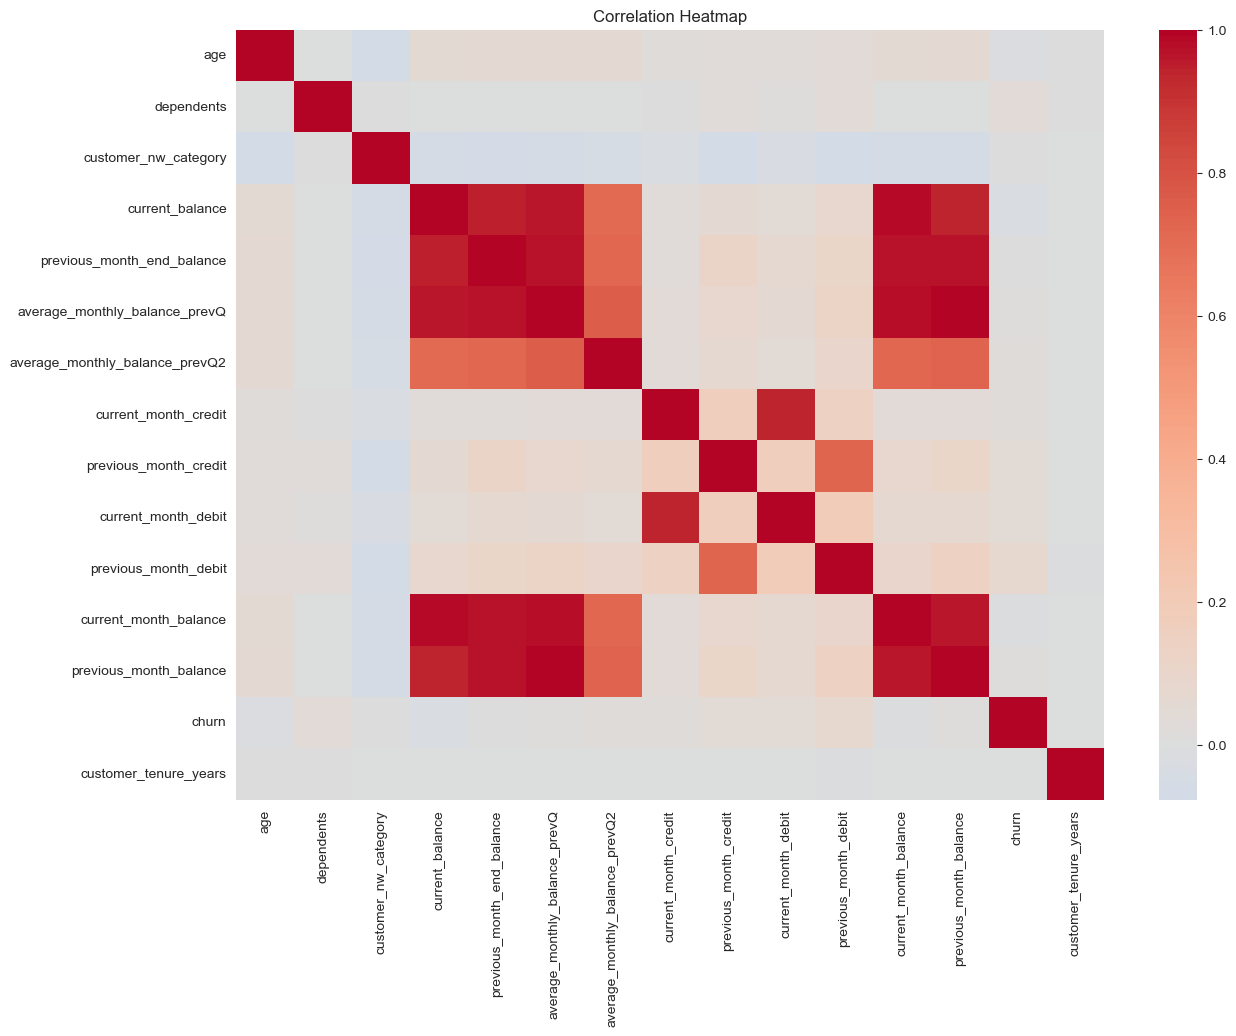

In [12]:
plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [14]:
corr["churn"].sort_values(ascending= False)

churn                             1.000000
previous_month_debit              0.073058
current_month_debit               0.048041
previous_month_credit             0.042179
dependents                        0.033685
current_month_credit              0.020755
average_monthly_balance_prevQ2    0.018376
previous_month_balance            0.014593
average_monthly_balance_prevQ     0.011960
previous_month_end_balance        0.006886
customer_nw_category              0.006551
customer_tenure_years            -0.004725
current_month_balance            -0.006391
age                              -0.020012
current_balance                  -0.024181
Name: churn, dtype: float64

## Correlation Interpretation

Review the variables with strongest positive or negative relationship with churn.

Expected insights:

- Negative correlation with balance may indicate higher-value customers churn less.
- Negative correlation with tenure may indicate loyal customers churn less.

## Correlation Insight

Current balance and customer tenure show negative association with churn, indicating more valuable and longer-tenure customers are less likely to churn.

# 2. Hypothesis Testing

Hypothesis testing is used to determine whether observed differences are statistically significant.

## Test 1: Do churned and retained customers have different balances?

### Null Hypothesis (H0):
Average current balance is equal for both groups.

### Alternative Hypothesis (H1):
Average current balance differs between groups.

In [15]:
retained = df[df["churn"] == 0]["current_balance"]
churned = df[df["churn"] == 1]["current_balance"]

stat, p = ttest_ind(retained, churned, equal_var=False)

print("T-statistic:", stat)
print("P-value:", p)

T-statistic: 5.576003209593436
P-value: 2.509813639978013e-08


## T-Test Result: Current Balance vs Churn

An independent two-sample t-test was conducted to compare the average current balance of retained customers (`churn = 0`) and churned customers (`churn = 1`).

- **T-statistic:** 5.576  
- **P-value:** 2.51e-08

### Interpretation

Since the p-value is significantly lower than 0.05, the null hypothesis is rejected.

This indicates that the average current balance of churned and retained customers is statistically different.

### Business Insight

Customer balance appears to be an important factor associated with churn. Customers with lower balances may be more likely to leave the bank, suggesting that lower-engagement or lower-value customers may require stronger retention strategies.

## Test 2: Is churn associated with gender?

### Null Hypothesis (H0):
Gender and churn are independent.

### Alternative Hypothesis (H1):
Gender and churn are associated.

In [16]:
table = pd.crosstab(df["gender"], df["churn"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 11.862741137017077
P-value: 0.0005726818953372824


## Interpretation

If p-value < 0.05:

Gender has statistically significant association with churn.

## Test 3: Is churn associated with occupation?

In [17]:
table = pd.crosstab(df["occupation"], df["churn"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 56.95008997367705
P-value: 1.2673587479192002e-11


# 3. Logistic Regression

Because churn is binary (0 = retained, 1 = churned), logistic regression is appropriate.

The model estimates which variables significantly impact churn probability.

In [20]:
X = df[
[
    "age",
    "dependents",
    "current_balance",
    "customer_tenure_years"
]]

y = df["churn"]


In [23]:
X = sm.add_constant(X)


In [24]:
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.476706
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                28382
Model:                          Logit   Df Residuals:                    28377
Method:                           MLE   Df Model:                            4
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                0.005573
Time:                        15:44:43   Log-Likelihood:                -13530.
converged:                       True   LL-Null:                       -13606.
Covariance Type:            nonrobust   LLR p-value:                 8.971e-32
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.2247      0.125     -9.803      0.000      -1.470      -0.

# Final Statistical Findings

1. Customer balance shows statistically significant difference across churn groups.

2. Customer tenure is an important predictor of churn.

3. Gender may or may not have meaningful impact depending on p-value.

4. Occupation may provide useful segmentation insight.

5. Lower-value and newer customers appear at higher churn risk.